# Eksperimen Real-World Studies

Notebook ini digunakan untuk menguji ulang dua studi kasus dunia nyata:

- System 1: Stroke recovery assistant
- System 2: Archive space project

Input wajib berada di `Dataset/real_world_studies.csv` dengan kolom:

- `System`
- `Requirements name`
- `Domain`
- `Problem`
- `Class`
- `Atributes`
- `Relationship`

Gunakan `Dataset/real_world_studies_template.csv` sebagai template. Jangan isi dari angka tabel paper saja; isi harus berupa teks kebutuhan lengkap dan anotasi expert kelas/atribut/relasi.

In [1]:
from pathlib import Path
import re
import string
from collections import defaultdict

import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

DATA_PATH = Path("Dataset/real_world_studies.csv")
TEMPLATE_PATH = Path("Dataset/real_world_studies_template.csv")
OUTPUT_DIR = Path("experiment_outputs/real_world_studies")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
lemmatizer = WordNetLemmatizer()

In [2]:
def download_nltk_resources():
    resources = [
        ("tokenizers/punkt", "punkt"),
        ("tokenizers/punkt_tab", "punkt_tab"),
        ("taggers/averaged_perceptron_tagger", "averaged_perceptron_tagger"),
        ("taggers/averaged_perceptron_tagger_eng", "averaged_perceptron_tagger_eng"),
        ("corpora/wordnet", "wordnet"),
        ("corpora/omw-1.4", "omw-1.4"),
        ("corpora/stopwords", "stopwords"),
    ]
    for lookup_name, download_name in resources:
        try:
            nltk.data.find(lookup_name)
        except (LookupError, OSError):
            nltk.download(download_name, quiet=True)

download_nltk_resources()

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"File {DATA_PATH} belum ada. Salin {TEMPLATE_PATH} menjadi {DATA_PATH}, "
        "lalu isi teks kebutuhan lengkap dan anotasi expert."
    )

raw = pd.read_csv(DATA_PATH)
required_columns = ["System", "Requirements name", "Domain", "Problem", "Class", "Atributes", "Relationship"]
missing_columns = [col for col in required_columns if col not in raw.columns]
if missing_columns:
    raise ValueError(f"Kolom wajib belum ada: {missing_columns}")

missing_values = raw[required_columns].isna() | raw[required_columns].astype(str).apply(lambda col: col.str.strip().eq(""))
if missing_values.any().any():
    bad = raw.loc[missing_values.any(axis=1), ["System", "Requirements name"]]
    raise ValueError(
        "Masih ada nilai kosong pada real_world_studies.csv. "
        f"Lengkapi baris berikut terlebih dahulu:\n{bad.to_string(index=False)}"
    )

display(raw)

,System,Requirements name,Domain,Problem,Class,Atributes,Relationship
0,System 1,Stroke recovery assistant,Health,The stroke recovery assistant supports patient...,"Patient, Therapist, Doctor, Session, Exercise,...","Patient [ID, Name], Therapist [ID], Doctor [ID...","Patient and Therapist, Patient and Session, Th..."
1,System 2,Archive space project,Information system,The archive space project manages physical roo...,"Archive, Room, Shelf, Box, Document, Archivist...","Archive [Name], Document [Code]","Archive and Room, Room and Shelf, Shelf and Bo..."


## Preprocessing dan Ground Truth Token-Level

In [4]:
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    if treebank_tag.startswith("V"):
        return wordnet.VERB
    if treebank_tag.startswith("N"):
        return wordnet.NOUN
    if treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

def normalize_label(value):
    value = str(value).strip().lower()
    return lemmatizer.lemmatize(value, pos="n")

def extract_class_attribute_mapping(attribute_string):
    class_attribute_mapping = {}
    class_attribute_groups = re.findall(r"(\w+)\s*\[([^\]]+)\]", str(attribute_string))
    for class_name, attributes in class_attribute_groups:
        class_name_lem = normalize_label(class_name)
        attributes_list = [attr.strip() for attr in attributes.split(",")]
        attributes_lem = [normalize_label(attr) for attr in attributes_list]
        class_attribute_mapping[class_name_lem] = attributes_lem
    return class_attribute_mapping

def parse_relationships(relationship_string):
    relationships = []
    for rel in str(relationship_string).split(","):
        rel = rel.strip()
        if " and " in f" {rel.lower()} ":
            parts = re.split(r"\s+and\s+", rel, maxsplit=1, flags=re.IGNORECASE)
            if len(parts) == 2:
                relationships.append(tuple(normalize_label(part) for part in parts))
    return relationships

def tag_problem_classes_and_attributes(problem_number, problem, class_attribute_mapping, class_list_lem, relationships, sentence_offset=0):
    rows = []
    sentence_counter = sentence_offset

    for sentence in nltk.sent_tokenize(str(problem)):
        sentence_counter += 1
        words = nltk.word_tokenize(sentence)
        words = [word for word in words if word.lower() not in string.punctuation]
        pos_tags = nltk.pos_tag(words)

        lemmatized_words = [
            lemmatizer.lemmatize(word.lower(), pos=get_wordnet_pos(pos))
            for word, pos in pos_tags
        ]
        lemmatized_sentence = " ".join(lemmatized_words)

        for word, lemmatized_word, pos in zip(words, lemmatized_words, [p for _, p in pos_tags]):
            tag = "Other"
            found_class = "Other"
            found_relationship = "Other"

            attribute_found = False
            for class_name, attributes in class_attribute_mapping.items():
                if lemmatized_word in attributes:
                    tag = "Attribute"
                    found_class = class_name
                    attribute_found = True
                    break

            if not attribute_found and lemmatized_word in class_list_lem:
                tag = "Class"
                found_class = lemmatized_word
                for rel in relationships:
                    if found_class in rel:
                        found_relationship = rel[1] if rel[0] == found_class else rel[0]
                        break

            rows.append({
                "Problem_Number": problem_number,
                "Sentence #": f"Sentence: {sentence_counter}",
                "Problem": problem,
                "Sentence": lemmatized_sentence,
                "Word": lemmatized_word,
                "POS": pos,
                "Tag": tag,
                "Class_Related": found_class,
                "Class_R": found_relationship,
            })

    return pd.DataFrame(rows), sentence_counter

def build_tagged_dataset(raw_df):
    tagged_data = []
    sentence_offset = 0
    for index, row in raw_df.iterrows():
        problem_number = index + 1
        class_list_lem = [normalize_label(cls) for cls in str(row["Class"]).split(",")]
        class_attribute_mapping = extract_class_attribute_mapping(row["Atributes"])
        relationships = parse_relationships(row["Relationship"])
        tagged_df, sentence_offset = tag_problem_classes_and_attributes(
            problem_number,
            row["Problem"],
            class_attribute_mapping,
            class_list_lem,
            relationships,
            sentence_offset,
        )
        tagged_df["System"] = row["System"]
        tagged_df["Requirements name"] = row["Requirements name"]
        tagged_df["Domain"] = row["Domain"]
        tagged_data.append(tagged_df)
    return pd.concat(tagged_data, ignore_index=True)

tagged = build_tagged_dataset(raw)
display(tagged.head(20))
print(tagged[["Tag", "Class_Related", "Class_R"]].nunique())

,Problem_Number,Sentence #,Problem,Sentence,Word,POS,Tag,Class_Related,Class_R,System,Requirements name,Domain
0,1,Sentence: 1,The stroke recovery assistant supports patient...,the stroke recovery assistant support patient ...,the,DT,Other,Other,Other,System 1,Stroke recovery assistant,Health
1,1,Sentence: 1,The stroke recovery assistant supports patient...,the stroke recovery assistant support patient ...,stroke,NN,Other,Other,Other,System 1,Stroke recovery assistant,Health
2,1,Sentence: 1,The stroke recovery assistant supports patient...,the stroke recovery assistant support patient ...,recovery,NN,Other,Other,Other,System 1,Stroke recovery assistant,Health
3,1,Sentence: 1,The stroke recovery assistant supports patient...,the stroke recovery assistant support patient ...,assistant,NN,Other,Other,Other,System 1,Stroke recovery assistant,Health
4,1,Sentence: 1,The stroke recovery assistant supports patient...,the stroke recovery assistant support patient ...,support,VBZ,Other,Other,Other,System 1,Stroke recovery assistant,Health
5,1,Sentence: 1,The stroke recovery assistant supports patient...,the stroke recovery assistant support patient ...,patient,NNS,Class,patient,therapist,System 1,Stroke recovery assistant,Health
6,1,Sentence: 1,The stroke recovery assistant supports patient...,the stroke recovery assistant support patient ...,during,IN,Other,Other,Other,System 1,Stroke recovery assistant,Health
7,1,Sentence: 1,The stroke recovery assistant supports patient...,the stroke recovery assistant support patient ...,home,NN,Other,Other,Other,System 1,Stroke recovery assistant,Health
8,1,Sentence: 1,The stroke recovery assistant supports patient...,the stroke recovery assistant support patient ...,rehabilitation,NN,Other,Other,Other,System 1,Stroke recovery assistant,Health
9,1,Sentence: 2,The stroke recovery assistant supports patient...,each patient have a profile and follow a recov...,each,DT,Other,Other,Other,System 1,Stroke recovery assistant,Health


Tag               3
Class_Related    21
Class_R          15
dtype: int64


## Table 5: Statistik Real-World Studies

In [5]:
stop_words = set(stopwords.words("english"))

def count_attributes(attribute_string):
    mapping = extract_class_attribute_mapping(attribute_string)
    return sum(len(attrs) for attrs in mapping.values())

def count_relationships(relationship_string):
    return len(parse_relationships(relationship_string))

stats_rows = []
for _, row in raw.iterrows():
    sentences = nltk.sent_tokenize(str(row["Problem"]))
    words = [
        token.lower()
        for sentence in sentences
        for token in nltk.word_tokenize(sentence)
        if token.lower() not in string.punctuation
    ]
    no_stop = [word for word in words if word not in stop_words]
    classes = [cls.strip() for cls in str(row["Class"]).split(",") if cls.strip()]

    stats_rows.append({
        "No": row["System"],
        "Requirements name": row["Requirements name"],
        "Domain": row["Domain"],
        "Sentences": len(sentences),
        "Words": len(words),
        "Unique words": len(set(words)),
        "Stop words removed": len(no_stop),
        "Classes": len(classes),
        "Attributes": count_attributes(row["Atributes"]),
        "Relationships": count_relationships(row["Relationship"]),
    })

table5 = pd.DataFrame(stats_rows)
display(table5)
table5.to_csv(OUTPUT_DIR / "table5_real_world_statistics.csv", index=False)

,No,Requirements name,Domain,Sentences,Words,Unique words,Stop words removed,Classes,Attributes,Relationships
0,System 1,Stroke recovery assistant,Health,12,142,93,95,13,10,5
1,System 2,Archive space project,Information system,11,120,75,79,11,2,6


## Load Model LR, RF, dan XGBoost

In [6]:
class XGBLabelEncodedClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=1.0,
        random_state=42,
        tree_method="hist",
        n_jobs=-1,
    ):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.subsample = subsample
        self.random_state = random_state
        self.tree_method = tree_method
        self.n_jobs = n_jobs

    def fit(self, X, y):
        from xgboost import XGBClassifier

        self.label_encoder_ = LabelEncoder()
        y_encoded = self.label_encoder_.fit_transform(y)
        self.classes_ = self.label_encoder_.classes_
        self.model_ = XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            learning_rate=self.learning_rate,
            subsample=self.subsample,
            random_state=self.random_state,
            tree_method=self.tree_method,
            n_jobs=self.n_jobs,
        )
        self.model_.fit(X, y_encoded)
        return self

    def predict(self, X):
        y_encoded = self.model_.predict(X).astype(int)
        return self.label_encoder_.inverse_transform(y_encoded)

import __main__
XGBLabelEncodedClassifier.__module__ = "__main__"
__main__.XGBLabelEncodedClassifier = XGBLabelEncodedClassifier

MODEL_DIRS = {
    "Logistic Regression": Path("experiment_outputs/logistic_regression"),
    "Random Forest": Path("experiment_outputs/random_forest"),
    "XGBoost": Path("experiment_outputs/xgboost"),
}
MODEL_KEYS = {
    "Logistic Regression": "logistic_regression",
    "Random Forest": "random_forest",
    "XGBoost": "xgboost",
}

bundles = {}
for model_name, model_dir in MODEL_DIRS.items():
    key = MODEL_KEYS[model_name]
    bundles[model_name] = {
        "class_attribute": load(model_dir / f"{key}_class_attribute.joblib"),
        "class_attribute_relationship": load(model_dir / f"{key}_class_attribute_relationship.joblib"),
        "class_class_relationship": load(model_dir / f"{key}_class_class_relationship.joblib"),
    }

print("Loaded models:", list(bundles))

Loaded models: ['Logistic Regression', 'Random Forest', 'XGBoost']


## Table 6: Hasil Real-World Studies

In [7]:
def predict_task(bundle, task_name, feature_df):
    task_bundle = bundle[task_name]
    return task_bundle["best_estimator"].predict(feature_df[task_bundle["features"]])

def predict_cascade(bundle, parsed_df):
    predicted = parsed_df[["Sentence", "Word", "POS"]].copy()
    predicted["Tag"] = predict_task(bundle, "class_attribute", predicted)
    predicted["Class_Related"] = predict_task(bundle, "class_attribute_relationship", predicted)
    predicted["Class_R"] = predict_task(bundle, "class_class_relationship", predicted)
    predicted["System"] = parsed_df["System"].values
    predicted["Requirements name"] = parsed_df["Requirements name"].values
    predicted["Problem_Number"] = parsed_df["Problem_Number"].values
    return predicted

def aggregate_metrics(true_df, pred_df):
    rows = []
    for target in ["Tag", "Class_Related", "Class_R"]:
        report = classification_report(
            true_df[target].astype(str),
            pred_df[target].astype(str),
            output_dict=True,
            zero_division=0,
        )
        rows.append({
            "Accuracy": accuracy_score(true_df[target].astype(str), pred_df[target].astype(str)),
            "Precision": report["weighted avg"]["precision"],
            "Recall": report["weighted avg"]["recall"],
            "F1": report["weighted avg"]["f1-score"],
        })
    return pd.DataFrame(rows).mean()

all_predictions = []
table6_rows = []
detail_rows = []

for model_name, bundle in bundles.items():
    predictions = predict_cascade(bundle, tagged)
    predictions["Model"] = model_name
    all_predictions.append(predictions)

    for system in tagged["System"].unique():
        true_system = tagged[tagged["System"] == system]
        pred_system = predictions[predictions["System"] == system]
        metrics = aggregate_metrics(true_system, pred_system)
        row = {
            "Model": model_name,
            "Requirements": system,
            "Accuracy": round(metrics["Accuracy"] * 100, 2),
            "Precision": round(metrics["Precision"] * 100, 2),
            "Recall": round(metrics["Recall"] * 100, 2),
            "F1": round(metrics["F1"] * 100, 2),
        }
        table6_rows.append(row)

        for target in ["Tag", "Class_Related", "Class_R"]:
            report = classification_report(
                true_system[target].astype(str),
                pred_system[target].astype(str),
                output_dict=True,
                zero_division=0,
            )
            detail_rows.append({
                "Model": model_name,
                "Requirements": system,
                "Target": target,
                "Accuracy": round(accuracy_score(true_system[target].astype(str), pred_system[target].astype(str)) * 100, 2),
                "Precision": round(report["weighted avg"]["precision"] * 100, 2),
                "Recall": round(report["weighted avg"]["recall"] * 100, 2),
                "F1": round(report["weighted avg"]["f1-score"] * 100, 2),
            })

predictions_df = pd.concat(all_predictions, ignore_index=True)
table6 = pd.DataFrame(table6_rows)
table6_detail = pd.DataFrame(detail_rows)

display(table6)
display(table6_detail)

predictions_df.to_csv(OUTPUT_DIR / "real_world_predictions.csv", index=False)
table6.to_csv(OUTPUT_DIR / "table6_real_world_results.csv", index=False)
table6_detail.to_csv(OUTPUT_DIR / "table6_real_world_results_by_target.csv", index=False)

,Model,Requirements,Accuracy,Precision,Recall,F1
0,Logistic Regression,System 1,81.92,81.83,81.92,81.25
1,Logistic Regression,System 2,72.22,66.88,72.22,66.90
2,Random Forest,System 1,83.10,69.09,83.10,75.44
3,Random Forest,System 2,74.44,55.75,74.44,63.75
4,XGBoost,System 1,85.45,80.75,85.45,80.96
5,XGBoost,System 2,73.61,57.18,73.61,64.36


,Model,Requirements,Target,Accuracy,Precision,Recall,F1
0,Logistic Regression,System 1,Tag,80.99,86.26,80.99,82.21
1,Logistic Regression,System 1,Class_Related,80.99,81.20,80.99,80.73
2,Logistic Regression,System 1,Class_R,83.80,78.05,83.80,80.82
3,Logistic Regression,System 2,Tag,71.67,79.34,71.67,68.89
4,Logistic Regression,System 2,Class_Related,71.67,62.12,71.67,66.32
5,Logistic Regression,System 2,Class_R,73.33,59.18,73.33,65.50
6,Random Forest,System 1,Tag,81.69,66.73,81.69,73.46
7,Random Forest,System 1,Class_Related,81.69,66.73,81.69,73.46
8,Random Forest,System 1,Class_R,85.92,73.81,85.92,79.41
9,Random Forest,System 2,Tag,73.33,54.23,73.33,62.35


## Figure 5 Data: Expert vs Model Counts

In [8]:
def extract_expert_counts(row):
    return {
        "Class": len([cls.strip() for cls in str(row["Class"]).split(",") if cls.strip()]),
        "Attribute": count_attributes(row["Atributes"]),
        "Relationship": count_relationships(row["Relationship"]),
    }

def extract_model_counts(pred_df):
    classes = set(pred_df.loc[pred_df["Tag"].eq("Class"), "Word"].astype(str))
    attributes = set(pred_df.loc[pred_df["Tag"].eq("Attribute"), "Word"].astype(str))
    rel_rows = pred_df[
        pred_df["Tag"].eq("Class") &
        pred_df["Class_R"].astype(str).str.lower().ne("other")
    ]
    relationships = set(
        tuple(sorted((str(row["Word"]), str(row["Class_R"]))))
        for _, row in rel_rows.iterrows()
        if str(row["Word"]).lower() != str(row["Class_R"]).lower()
    )
    return {
        "Class": len(classes),
        "Attribute": len(attributes),
        "Relationship": len(relationships),
    }

figure_rows = []
for _, row in raw.iterrows():
    expert_counts = extract_expert_counts(row)
    for component, count in expert_counts.items():
        figure_rows.append({
            "Requirements": row["System"],
            "Source": "Expert",
            "Model": "Expert",
            "Component": component,
            "Count": count,
        })

    for model_name in bundles:
        pred_system = predictions_df[
            predictions_df["System"].eq(row["System"]) &
            predictions_df["Model"].eq(model_name)
        ]
        model_counts = extract_model_counts(pred_system)
        for component, count in model_counts.items():
            figure_rows.append({
                "Requirements": row["System"],
                "Source": "Model",
                "Model": model_name,
                "Component": component,
                "Count": count,
            })

figure5_data = pd.DataFrame(figure_rows)
display(figure5_data)
figure5_data.to_csv(OUTPUT_DIR / "figure5_expert_vs_model_counts.csv", index=False)

,Requirements,Source,Model,Component,Count
0,System 1,Expert,Expert,Class,13
1,System 1,Expert,Expert,Attribute,10
2,System 1,Expert,Expert,Relationship,5
3,System 1,Model,Logistic Regression,Class,6
4,System 1,Model,Logistic Regression,Attribute,7
5,System 1,Model,Logistic Regression,Relationship,8
6,System 1,Model,Random Forest,Class,0
7,System 1,Model,Random Forest,Attribute,0
8,System 1,Model,Random Forest,Relationship,0
9,System 1,Model,XGBoost,Class,3


## Visualisasi Figure 5

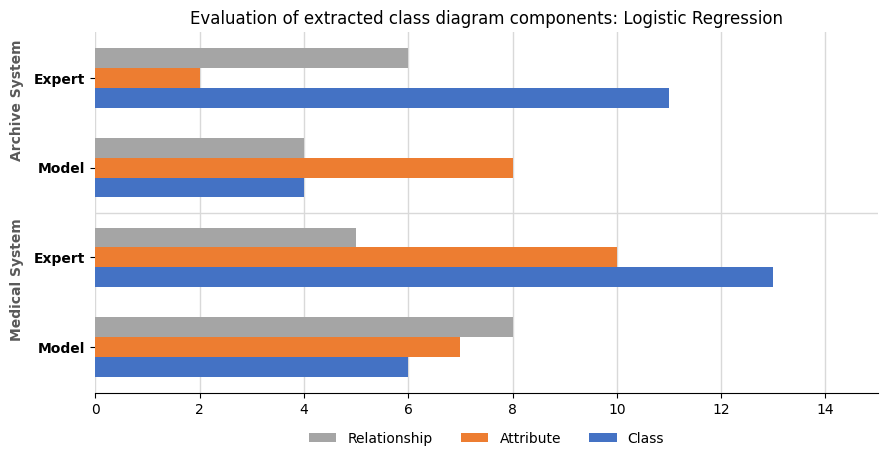

Saved: experiment_outputs\real_world_studies\figure5a_lr_expert_vs_model.png


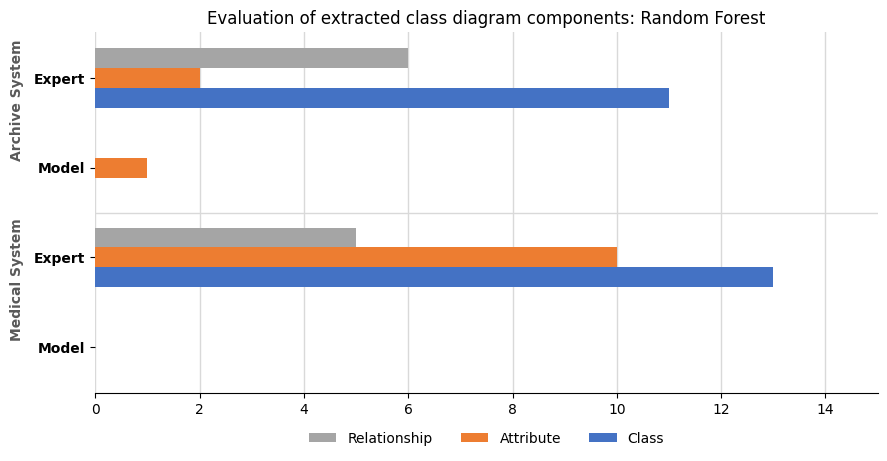

Saved: experiment_outputs\real_world_studies\figure5b_rf_expert_vs_model.png


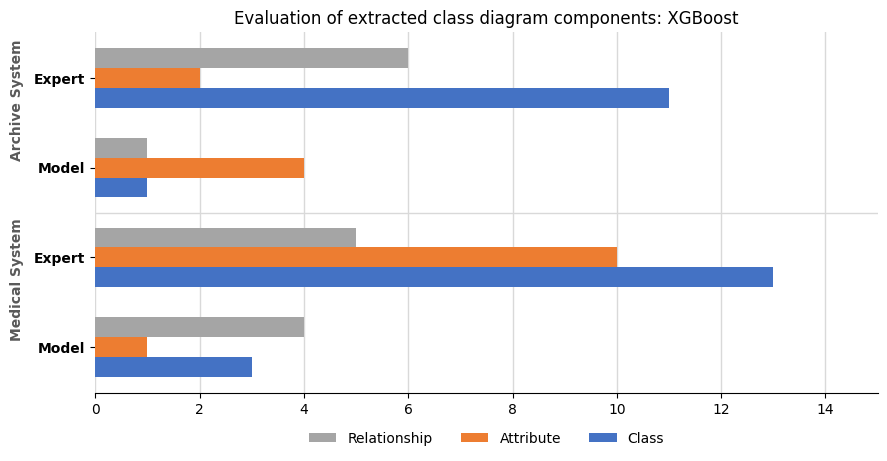

Saved: experiment_outputs\real_world_studies\figure5c_xgb_expert_vs_model.png


In [9]:
def plot_reference_vs_model(figure_data, model_name, output_path=None):
    components = ["Relationship", "Attribute", "Class"]
    colors = {"Relationship": "#A5A5A5", "Attribute": "#ED7D31", "Class": "#4472C4"}
    system_labels = {"System 1": "Medical System", "System 2": "Archive System"}

    rows = []
    labels = []
    for system in ["System 2", "System 1"]:
        for source_label, source_model in [("Expert", "Expert"), ("Model", model_name)]:
            subset = figure_data[
                figure_data["Requirements"].eq(system) &
                figure_data["Model"].eq(source_model)
            ]
            counts = {}
            for comp in components:
                val = subset[subset["Component"].eq(comp)]["Count"]
                counts[comp] = int(val.iloc[0]) if len(val) else 0
            rows.append((system, source_label, counts))
            labels.append(source_label)

    y = list(range(len(rows)))
    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    bar_height = 0.22
    offsets = {"Relationship": -bar_height, "Attribute": 0, "Class": bar_height}

    for comp in components:
        values = [row[2][comp] for row in rows]
        ax.barh(
            [pos + offsets[comp] for pos in y],
            values,
            height=bar_height,
            color=colors[comp],
            label=comp,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontweight="bold")
    ax.invert_yaxis()
    max_count = max(max(row[2].values()) for row in rows)
    ax.set_xlim(0, max(14, max_count + 2))
    ax.grid(axis="x", color="#D9D9D9", linewidth=1)
    ax.set_axisbelow(True)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
    ax.set_title(f"Evaluation of extracted class diagram components: {model_name}")

    ax.text(
        -0.10, 0.25, system_labels["System 2"],
        transform=ax.get_yaxis_transform(),
        rotation=90,
        va="center",
        ha="center",
        fontweight="bold",
        color="#595959",
    )
    ax.text(
        -0.10, 2.25, system_labels["System 1"],
        transform=ax.get_yaxis_transform(),
        rotation=90,
        va="center",
        ha="center",
        fontweight="bold",
        color="#595959",
    )
    ax.axhline(1.5, color="#D9D9D9", linewidth=1)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout(rect=[0.06, 0.08, 1, 1])
    if output_path is not None:
        fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

figure_paths = {
    "Logistic Regression": OUTPUT_DIR / "figure5a_lr_expert_vs_model.png",
    "Random Forest": OUTPUT_DIR / "figure5b_rf_expert_vs_model.png",
    "XGBoost": OUTPUT_DIR / "figure5c_xgb_expert_vs_model.png",
}

for model_name, output_path in figure_paths.items():
    plot_reference_vs_model(figure5_data, model_name, output_path)
    print(f"Saved: {output_path}")